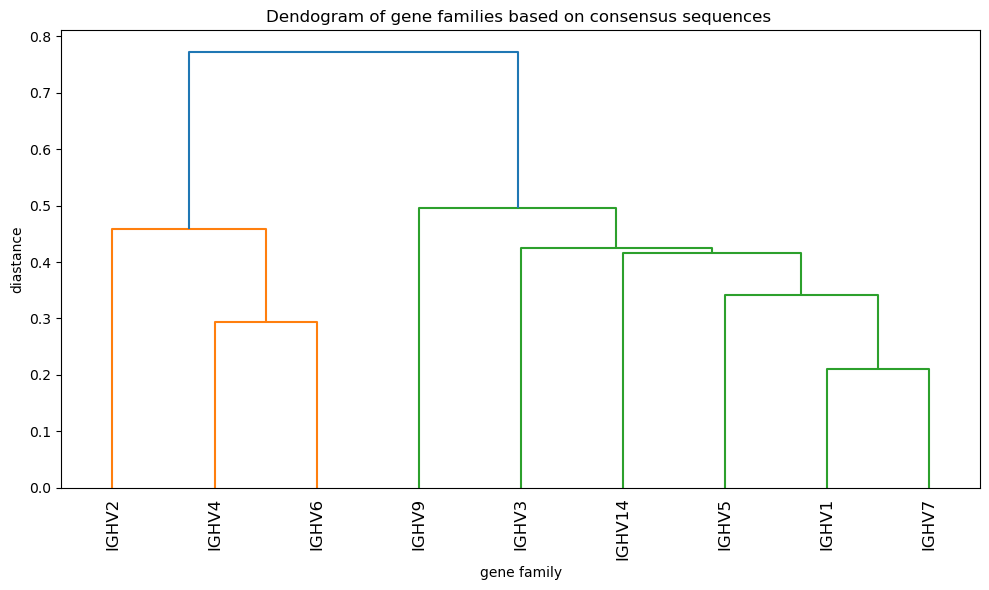

In [1]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, to_tree
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from io import StringIO

# 1. Distance Matrix einlesen
file_path = "msa_consensus_output/distance_matrix.txt"

with open(file_path, "r") as f:
    lines = f.readlines()

# Anzahl der Sequenzen
n = int(lines[0].strip())

# Labels und Matrix extrahieren
labels = []
matrix = []

for line in lines[1:]:
    parts = line.strip().split()
    label = parts[0]
    values = list(map(float, parts[1:]))
    labels.append(label)
    matrix.append(values)

# 2. In ein DataFrame umwandeln
df = pd.DataFrame(matrix, index=labels, columns=labels)

# 3. In ein condensed Distance Array umwandeln (für linkage)
condensed_dist = squareform(df.values)

# 4. Hierarchisches Clustering (z.B. UPGMA / average linkage)
Z = linkage(condensed_dist, method='ward')

# 5. Dendrogramm zeichnen
plt.figure(figsize=(10, 6))
dendrogram(Z, labels=labels, leaf_rotation=90)
plt.title("Dendogram of gene families based on consensus sequences ")
plt.xlabel("gene family")
plt.ylabel("diastance")
plt.tight_layout()
plt.savefig("msa_consensus_output/consensus_tree.png")
plt.show()

Code for "Dendogram of gene families basen on consensus sequences"

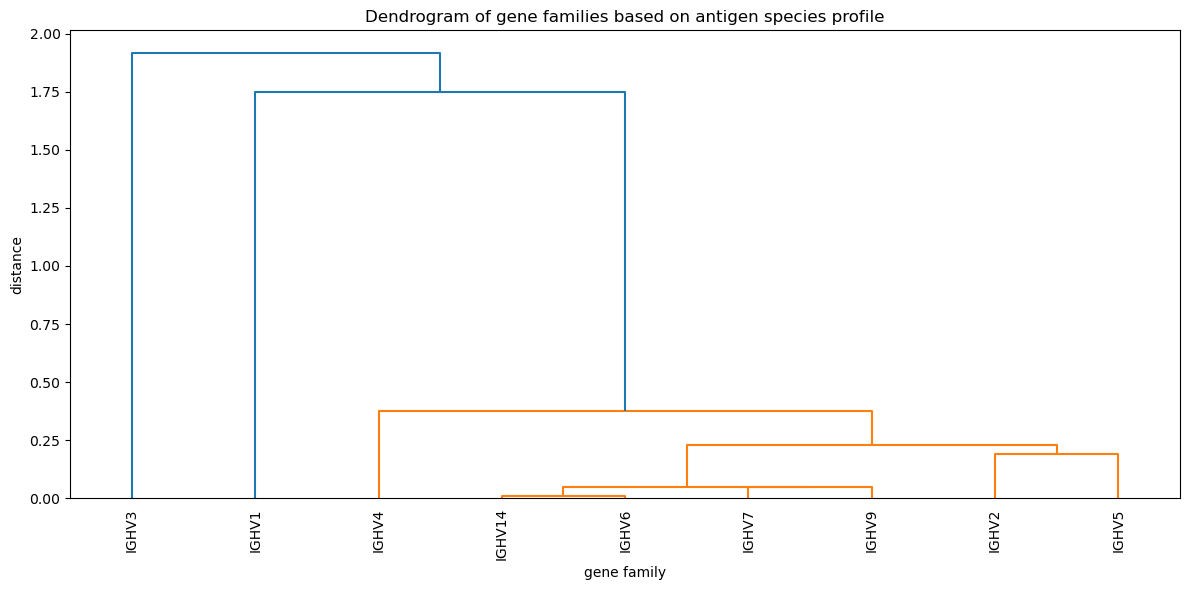

Cophenetische Korrelation der beiden Cluster: -0.188


In [3]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# -------------------------------
# 1. CSV einlesen
# -------------------------------
df = pd.read_csv("../../data_cleanup/df_sars_hum_cleaned_final.csv", sep="\t")

# -------------------------------
# 2. Spalte aufsplitten und explodieren
# -------------------------------
df["antigen_species"] = df["antigen_species"].str.split("|").apply(lambda x: [s.strip() for s in x])
df_exploded = df.explode("antigen_species")

# -------------------------------
# 3. Nur gewünschte Spezies behalten
# -------------------------------
relevant_species = ["severe acute respiratory syndrome coronavirus2", "homo sapiens"]
df_filtered = df_exploded[df_exploded["antigen_species"].isin(relevant_species)]

# -------------------------------
# 4. Pivot: Häufigkeit von species pro heavy_subclass
# -------------------------------
pivot = df_filtered.pivot_table(
    index="heavy_subclass",
    columns="antigen_species",
    aggfunc="size",
    fill_value=0
)

# -------------------------------
# 5. Standardisieren (Z-Scores) — optional
# -------------------------------
pivot_scaled = StandardScaler().fit_transform(pivot)

# -------------------------------
# 6. Hierarchisches Clustering (Ward)
# -------------------------------
linkage_matrix = linkage(pivot_scaled, method="single", metric="euclidean")

# -------------------------------
# 7. Dendrogramm plotten
# -------------------------------
plt.figure(figsize=(12, 6))
dendrogram(
    linkage_matrix,
    labels=pivot.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=None
)

plt.title("Dendrogram of gene families based on antigen species profile")
plt.xlabel("gene family")
plt.ylabel("distance")
plt.tight_layout()
plt.show()


from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

# --- 3. Cophenetische Distanzen für beide Cluster berechnen ---

coph_dist_1 = cophenet(Z, condensed_dist)[1]

pivot_dist = pdist(pivot_scaled, metric='euclidean')
coph_dist_2 = cophenet(linkage_matrix, pivot_dist)[1]

# --- 4. Cophenetische Korrelation zwischen beiden Clustern berechnen ---

correlation = np.corrcoef(coph_dist_1, coph_dist_2)[0, 1]

print(f"Cophenetische Korrelation der beiden Cluster: {correlation:.3f}")

Code for "Dendogram of gene families based on antigen species profile.

Also contains a cophenetic clustering to compare both dendograms with eachother.